## 7. Métodos de Newton-Raphson e das secantes

### 7.1. Método de Newton-Raphson

O _Método de Newton_  (_Newton-Raphson_ ou _método das tangentes_) para zeros de funções reais em variável pode ser deduzido a partir do método do ponto fixo ao buscar uma função de interação $\phi(x)$ tal que $|\phi'(x)|<1$. Dessa forma, escolhendo-se uma "boa" aproximação inicial $x_0$ garantimos que a sequência de soluções aproximadas irá convergir para a solução exata $\overline{x}$.

Para isso, estabelecemos que $|\phi'(\overline{x})|=0$, assim, espera-se que em torno de $\overline{x}$ tenhamos $|\phi'(x)|<1$, então escrevemos uma forma geral para a função $\phi(x)$ multiplicando $f(x)=0$ por uma função desconhecida $\theta(x)$ e somamos $x$ em ambos os lados da equação obtendo

$$x = x+\theta(x)f(x)$$ 
 
 ou
 
$$\phi(x) = x+\theta(x)f(x)$$ 

nas quais $\theta(x)$ é uma função de $x$ tal que $\theta(\overline{x})\neq 0$. Então, para o ponto fixo $x=\overline{x}$ tem-se $\phi(\overline{x}) = \overline{x}$. Assim, derivando a função $\phi(x)$ e avaliando no ponto fixo obtemos:

$$\phi'(x) = 1+\theta'(x)f(x) + \theta(x)f'(x)$$

avaliando em $\overline{x}$

$$\phi'(\overline{x}) = 1+\theta'(\overline{x})f(\overline{x}) + \theta(\overline{x})f'(\overline{x})$$


$$ 0 = 1 + \theta(\overline{x})f'(\overline{x}) $$

então temos 

$$  \theta(\overline{x}) = -\frac{1}{f'(\overline{x})} $$

Assim, escolhento $\theta(x) = -\frac{1}{f'(x)}$ e substituindo em $\Phi(x) = x+\theta(x)f(x)$ obtemos

$$ \phi(x) = x - \frac{f(x)}{f'(x)}$$

que fornece o processo iterativo do método de Newton por meio de:

$$ x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}$$

Desde que  $f'(x_i) \neq 0$, a cada iteração o ponto $x_{i+1}$ corresponde à intersecção da reta tangente à função $f(x)$ no ponto $(x_i, f(x_i))$, assim, o método de Newton pode ser interpretado geometricamente como mostra a figura 4.4 abaixo.

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/refs/heads/main/07_metodos_de_newton-raphson_e_das_tangentes/figuras/newton.png" width="480">
Figura 4.4 - Interpretação geométrica do método de Newton


O método de Newton também pode ser deduzido a partir do polinômio de Taylor em torno de $x_0$:

$$f(x) = f(x_0)+
        f^{(1)}(x_0)(x-x_0)+ 
        f^{(2)}(x_0)\frac{(x-x_0)^2}{2!}+
        f^{(3)}(x_0)\frac{(x-x_0)^3}{3!}+...$$
        
desprezando os termos de maior grau, os quais assumem valores muito pequenos para $x$ suficientemente próximo de $x_0$, obtemos a seguinte aproximação para $f(x)$:

$$f(x) \approx f(x_0)+f'(x_0)(x-x_0)$$

fazendo $x=\overline{x}$, como $f(\overline{x})=0$, tem-se:

$$0 \approx f(x_0)+f'(x_0)(\overline{x}-x_0)$$

ou

$$\overline{x} \approx x_0 - \frac{f(x_0)}{f'(x_0)}$$

que fornece o processo iterativo 

$$ x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)} \,,\,\,\,\,\, i=1,2,...$$

Vejamos agora alguns exemplos. 

**Exemplo 7.1:** Vamos encontrar a raiz de $f(x)=ln(x)+x-4$ usando o método de Newton.

Para obter uma aproximação inicial podemos usar o recurso gráfico fazendo.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(4,3)

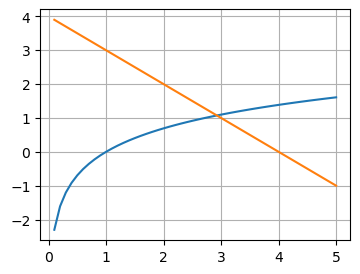

In [4]:
xi = np.linspace(0.1, 5)
plt.plot(xi, np.log(xi), xi, 4-xi) 
plt.grid()
plt.show()

O gráfico mostra que existe uma raiz entre 2 e 3, então, iniciando com $x_0=2$ obtemos pelo método de Newton:

$x_1 = x_0-\frac{f(x_0)}{f'(x_0)}=2-\frac{ln(2) +2 -4}{1/2+1}=2.871235$

$x_2 = x_1-\frac{f(x_1)}{f'(x_1)}=2-\frac{ln(2.871235) +2.871235-4}{1/2.871235+1}=2.926137$

$x_3 = x_2-\frac{f(x_2)}{f'(x_2)}=2.926137-\frac{ln(2.926137) +2.926137 -4}{1/2.926137+1}=2.926271$

Assim, em três interações chega-se a uma solução com $E=0.000046$. Usando Python podemos chegar a esses resultados com o código mostrado abaixo:

In [7]:
f = lambda x: np.log(x)+x-4.0
df = lambda x: 1./x +1  
x = 2
x_ant = x
err = 10.0

while err>0.0001:
    x = x - f(x)/df(x)
    err = abs(x-x_ant)/abs(x)
    x_ant = x
    print ("| x=%.6f"%x, "| err=%.6f"%err)

| x=2.871235 | err=0.303436
| x=2.926137 | err=0.018762
| x=2.926271 | err=0.000046


Observe que neste exemplo a derivada $f'(x)$ foi escrita explicitamente no código como `df = lambda x: 1./x +1`. Em Python, podemos combinar computação simbólica com numérica de modo a obter uma expressão para a derivada de uma função $f(x)$ de forma automática. 

Por exemplo, escrevendo a função $f(x)=ln(x)+x-4$ como uma expressão do `sympy` podemos obter a derivada como é mostrado abaixo.

In [10]:
import sympy as sp
x = sp.symbols('x')
expr = sp.log(x)+x-4.0
sp.diff(expr)

1 + 1/x

Para converter a expressão uma `sympy` em uma função `lambda` do `numpy` utilizamos `sympy.lambdify` como é mostrado a seguir:  

In [11]:
f = sp.lambdify((x), expr, 'numpy')
df = sp.lambdify((x), sympy.diff(expr), 'numpy')

Dessa forma podemos usar o mátodo de Newton sem ter que calcular a derivada de $f(x)$ previamente. 

### 7.2 Método das secantes

O método das secantes consiste em aproximarmos a derivada $f'(x_i)$ do método de Newton, que ocorre da seguinte forma:

$$ f'(x_i) \approx \frac{f(x_i) - f(x_{i-1})}{x_i-x_{i-1}}$$


Observe que, neste caso, estamos trocando a inclinação da reta tangente pela inclinação da reta secante à curva, conforme a figura abaixo. Assim, dados os pontos $x_{i−1}$ e $x_i$ , onde a reta secante, passando por $(x_{i−1}, f(x_{i−1}) )$ e $(x_i , f(x_i))$, cortar o eixo das abscissas, temos a aproximação $x_{i+1}$ para a raiz $\overline{x}$, conforme ilustrado 

<img src="https://raw.githubusercontent.com/tiagoburiol/MatComp_I/refs/heads/main/07_metodos_de_newton-raphson_e_das_tangentes/figuras/secantes.png" width="500">

Assim, o método de Newton, dado por

$$ x_{i+1} = x_i-\frac{f(x_i)}{f'(x_i)}$$

é modificado da seguinte forma

$$ x_{i+1} = x_i-\frac{ f(x_i)}{ \,\, \frac{f(x_i) - f(x_{i-1})}{x_i-x_{i-1}}\,\,}$$

Que pode ser reescrito como 

$$ x_{i+1} = x_i-\frac{ x_{i-1}f(x_i) - x_i f(x_{i-1})}{ f(x_i) - f(x_{i-1})}$$

**Exemplo 7.2:** Vamos agora encontrar a raiz da equação $ln(x)+x-4=0$ com tolerância $\epsilon = 0.0001$ usando o método das secantes.

Com base no que já foi feito no exemplo 4.11 podemos obter as iterações com o código mostrado a seguir.

In [70]:
err = 10.0
x0 = 1.0
x1 = 2.0

f = lambda x: math.log(x)+x-4.0

while err> 0.0001:
    x = (x0*f(x1)-x1*f(x0))/(f(x1)-f(x0))
    err = abs(x-x1)/abs(x) 
    x0 = x1
    x1 = x
    print ("x=%.9f"%x, "E=%.9f"%err)

x=2.771848327 E=0.278459799
x=2.918482896 E=0.050243422
x=2.926217104 E=0.002643074
x=2.926271044 E=0.000018433


#### Exercícios 
1. Calcule, se possível, as raízes das seguintes funções com pelo menos 3 casas de precisão:

a) $f(x) = \sqrt{x}-5^{-x}$  

b) $f(x) = e^{x} + x$

c) $f(x) = xln(x)-1$

d) $f(x) = sen(x)-1/2$

e) $x^3-7x^2+14x-6=0$  

f) $2x cos(2x)-(x+1)^2=0$

g) $x-2^{-x}=0$

h) $2+cos(e^x-2)-e^x=0$

i) $f(x) = –0.5x^2 + 2.5x + 4.5$

j) $f(x) = 5x^2 – 5x^2 + 6x -2$

k) $f(x) = –25 + 82x – 90x^2 + 44x^3 – 8x^4 + 0.7x^5$

l) $f(x) = – 12 – 21x + 18x^2 – 2.75x^3$